### Setup & Imports

In [1]:
import os
import pandas as pd
from datasets import load_dataset
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
import gradio as gr

# Load environment variables from .env file
load_dotenv()
groq_key = os.environ.get('groq_api_keys')
# Initialize LLM
llm = ChatGroq(model="llama-3.3-70b-versatile", api_key=groq_key)

print("✅ Setup complete. API Key loaded.")

✅ Setup complete. API Key loaded.


### THE INTRO - LLM vs. RAG Comparison

In [2]:
# Load data from huggingface for astro arxiv papers
from datasets import load_dataset
ds = load_dataset("mehnaazasad/arxiv_astro_co_ga")

In [3]:
ds

DatasetDict({
    train: Dataset({
        features: ['title', 'abstract'],
        num_rows: 79727
    })
    validation: Dataset({
        features: ['title', 'abstract'],
        num_rows: 9966
    })
    test: Dataset({
        features: ['title', 'abstract'],
        num_rows: 9966
    })
})

In [4]:
# example 
ds["train"]["abstract"][0]

'  We present a method to build a probability density function (pdf) for the age\nof a star based on its peculiar velocities $U$, $V$ and $W$ and its orbital\neccentricity. The sample used in this work comes from the Geneva-Copenhagen\nSurvey (GCS) which contains both the spatial velocities, orbital eccentricities\nand isochronal ages for about $14\\,000$ stars. Using the GCS stars, we fitted\nthe parameters that describe the relations between the distributions of\nkinematical properties and age. This parametrization allows us to obtain an age\nprobability from the kinematical data. From this age pdf, we estimate an\nindividual average age for the star using the most likely age and the expected\nage. We have obtained the stellar age pdf for the age of $9\\,102$ stars from\nthe GCS and have shown that the distribution of individual ages derived from\nour method is in good agreement with the distribution of isochronal ages. We\nalso observe a decline in the mean metallicity with our ages

In [5]:
# 1. Direct LLM (No Context)
question = "What is Trappist-1 age'?"

print("🤖 [DIRECT LLM RESPONSE - No Context]")
print("*" * 120)
direct_response = llm.invoke(question)
print(direct_response.content)
print("-" * 120)

# 2. RAG Style (Manually providing Context)
# We "pretend" we retrieved this from our CSV
sample_context = ds["train"]["abstract"][0] 

rag_prompt_intro = f"""Use the following context to answer the question. 
Context: {sample_context}
Question: {question}"""

print("🚀 [RAG RESPONSE - With Context]")
print("*" * 120)
rag_response = llm.invoke(rag_prompt_intro)
print(rag_response.content)

print("-" * 120)
print("\n💡 NOTICE THE DIFFERENCE:")
print("The Direct LLM gave a general answer. The RAG response gave the EXACT recommendation from our context.")

🤖 [DIRECT LLM RESPONSE - No Context]
************************************************************************************************************************
The Trappist-1 system is estimated to be around 7.6 billion years old. For comparison, the Sun and the Solar System are about 4.6 billion years old. Trappist-1 is an ultra-cool dwarf star, and its advanced age is likely due to its small size and low mass, which result in a slower rate of nuclear reactions in its core. Despite its age, Trappist-1 is still shining and hosting a system of seven Earth-sized planets, making it a fascinating target for exoplanet research and the search for life beyond Earth.
------------------------------------------------------------------------------------------------------------------------
🚀 [RAG RESPONSE - With Context]
************************************************************************************************************************
According to the text, the estimated age of Trappist-1 is 12

### Data Configuration (you will change this later with your dataset)

In [6]:
# --- CONFIGURATION: CHANGE THESE TO USE YOUR OWN DATA ---
ds = load_dataset("mehnaazasad/arxiv_astro_co_ga")
data = ds["test"]["abstract"][:50] # take first examples

### Create the Vector Store

In [7]:
# 1. Initialize the Embedding Model (Converts text to math)
embed_model = HuggingFaceEmbeddings(model_name="mixedbread-ai/mxbai-embed-large-v1")

# 2. Create and Populate Vector Store
vectorstore = Chroma(
    collection_name="dataset_store",
    embedding_function=embed_model,
    persist_directory="./chroma_db",
)


vectorstore.add_texts(data)
retriever = vectorstore.as_retriever()



print("🧠 Vector Store created. The AI can now 'search' your data.")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

🧠 Vector Store created. The AI can now 'search' your data.


In [14]:
query = "what is dark matter?"
results = vectorstore.similarity_search_with_score(query, k=3)

for i, (doc, score) in enumerate(results):
    print(f"--- Result {i+1} ---")
    print(f"Score (Distance): {score:.4f}")
    print(f"Content: {doc.page_content}")
    print("-" * 30)


--- Result 1 ---
Score (Distance): 252.7896
Content:   The MIMAC project is a multi-chamber detector for Dark Matter search, aiming
at measuring both track and ionization with a matrix of micromegas micro-TPC
filled with He3 and CF4. Recent experimental results on the first measurements
of the Helium quenching factor at low energy (1 keV recoil) are presented,
together with the first simulation of the track reconstruction. Recontruction
of track of alpha from Radon impurities is shown as a first proof of concept.

------------------------------
--- Result 2 ---
Score (Distance): 270.8379
Content:   We perform controlled numerical experiments to asses the effect of baryon
mass loss on the inner structure of large galactic dark matter haloes. This
mass expulsion is intended to mimic both the supernovae and AGN feedbacks, as
well as the evolution of stellar populations. This study is meant in particular
for precursors of massive Early Type Galaxies, wherein strong AGN feedback
(often dubb

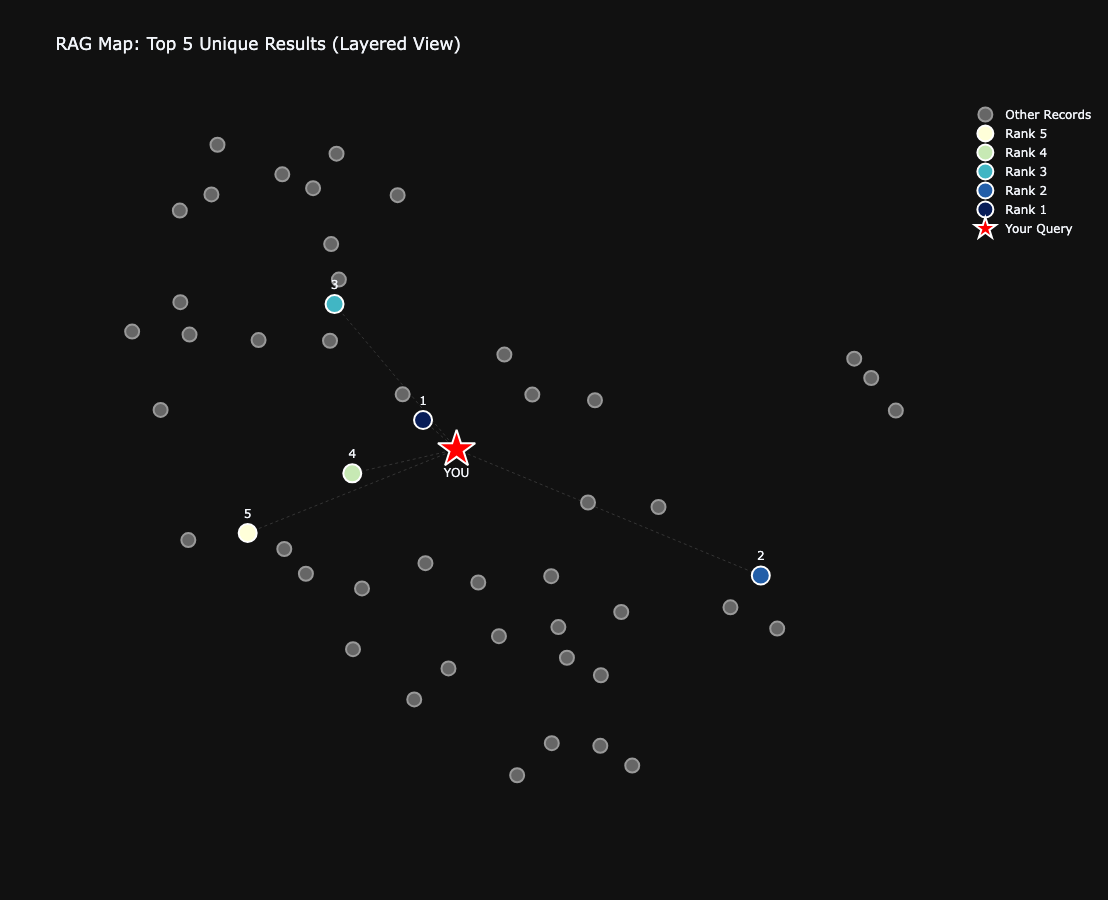

In [15]:
import textwrap
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.manifold import TSNE 
import numpy as np

def wrap_text(text, width=60):
    return "<br>".join(textwrap.wrap(text, width=width)) if text else ""

def visualize_rag_neighborhood(query_text, k=5):
    # 1. Fetch data (IDs are included by default)
    data = vectorstore._collection.get(include=['embeddings', 'documents'])
    all_embeddings = np.array(data['embeddings'])
    all_docs = data['documents']
    all_ids = data['ids'] 
    
    # 2. Get Query Embedding
    query_vector = np.array(embed_model.embed_query(query_text)).reshape(1, -1)
    
    # 3. Retrieve Top K Unique Records
    raw_results = vectorstore._collection.query(
        query_embeddings=query_vector.tolist(),
        n_results=20, 
        include=['documents', 'distances']
    )
    
    unique_retrieved = {}
    seen_texts = set()
    current_rank = 1
    for i in range(len(raw_results['ids'][0])):
        txt, idx, dist = raw_results['documents'][0][i], raw_results['ids'][0][i], raw_results['distances'][0][i]
        if txt not in seen_texts:
            unique_retrieved[idx] = (current_rank, dist)
            seen_texts.add(txt)
            current_rank += 1
        if len(unique_retrieved) == k: break

    # 4. t-SNE Reduction
    combined_vectors = np.vstack([all_embeddings, query_vector])
    perp = min(5, len(all_docs) - 1) if len(all_docs) > 1 else 1
    tsne = TSNE(n_components=2, perplexity=perp, init='pca', learning_rate='auto', random_state=42)
    coords = tsne.fit_transform(combined_vectors)
    db_coords, query_coord = coords[:-1], coords[-1]

    # 5. Build Dataframe
    plot_data = []
    line_traces = [] 
    for i, id_val in enumerate(all_ids):
        x, y = db_coords[i]
        text = all_docs[i]
        if id_val in unique_retrieved:
            rank, score = unique_retrieved[id_val]
            plot_data.append({
                'x': x, 'y': y, 'Category': f'Rank {rank}',
                'HoverText': f"<b>RANK: {rank}</b><br>Dist: {score:.4f}<br><br>{wrap_text(text)}",
                'Label': str(rank)
            })
            line_traces.append(go.Scatter(
                x=[query_coord[0], x], y=[query_coord[1], y],
                mode='lines', line=dict(color='rgba(255, 255, 255, 0.15)', width=1, dash='dot'),
                showlegend=False, hoverinfo='skip'
            ))
        else:
            plot_data.append({
                'x': x, 'y': y, 'Category': 'Other Records',
                'HoverText': f"Not Retrieved<br><br>{wrap_text(text)}", 'Label': ""
            })
    df = pd.DataFrame(plot_data)

    # 6. COLORS & ORDER
    # Define the exact order you want in the legend
    legend_order = [f"Rank {i+1}" for i in range(k)] + ["Other Records"]
    
    # --- STEP 6: COLORS & CATEGORY LISTS ---
    colorscale = px.colors.sequential.YlGnBu_r 
    rank_colors = [colorscale[i] for i in np.linspace(0, len(colorscale)-1, k).astype(int)]
    
    # Map colors
    color_map = {f"Rank {i+1}": rank_colors[i] for i in range(k)}
    color_map["Other Records"] = "#666666" 

    # --- STEP 7: CREATE FIGURE (ORDERED LAYERING) ---
    fig = go.Figure()

    # LAYER 1 (BOTTOM): Background lines
    for line in line_traces: 
        fig.add_trace(line)

    # LAYER 2 (MIDDLE): Other Records (Background Dots)
    # We add this trace first so it is at the bottom of the map
    others_df = df[df['Category'] == 'Other Records']
    if not others_df.empty:
        fig.add_trace(go.Scatter(
            x=others_df['x'], y=others_df['y'], 
            name='Other Records',
            mode='markers',
            customdata=others_df['HoverText'],
            marker=dict(size=14, color=color_map["Other Records"], opacity=1.0, line=dict(width=2, color='#999999')),
            hovertemplate="%{customdata}<extra></extra>"
        ))

    # LAYER 3 (TOP): Rank Dots
    # We loop backwards from Rank K to Rank 1 so that Rank 1 is the absolute top-most layer
    rank_categories = [f"Rank {i+1}" for i in range(k)]
    for cat in reversed(rank_categories):
        sub_df = df[df['Category'] == cat]
        if not sub_df.empty:
            fig.add_trace(go.Scatter(
                x=sub_df['x'], y=sub_df['y'], 
                name=cat,
                mode='markers+text', 
                text=sub_df['Label'], 
                textposition="top center",
                customdata=sub_df['HoverText'],
                marker=dict(
                    size=18, # Rank dots are larger
                    color=color_map[cat], 
                    opacity=1.0, 
                    line=dict(width=2, color='white') # Thick white border to pop
                ),
                hovertemplate="%{customdata}<extra></extra>"
            ))

    # LAYER 4 (ABSOLUTE TOP): The Query Star
    fig.add_trace(go.Scatter(
        x=[query_coord[0]], y=[query_coord[1]],
        mode='markers+text', name='Your Query', text=["YOU"], textposition="bottom center",
        marker=dict(symbol='star', size=28, color='red', line=dict(width=2, color='white')),
        hovertemplate=f"YOUR QUERY:<br>{wrap_text(query_text)}<extra></extra>"
    ))

    # --- STEP 8: LAYOUT & LEGEND ORDER ---
    # We force the legend to show Rank 1 at the top regardless of trace order
    legend_order = [f"Rank {i+1}" for i in range(k)] + ["Other Records"]
    
    fig.update_layout(
        title=f"RAG Map: Top {k} Unique Results (Layered View)",
        template="plotly_dark", width=900, height=900,
        xaxis=dict(showgrid=False, showticklabels=False, zeroline=False),
        yaxis=dict(showgrid=False, showticklabels=False, zeroline=False),
        hoverlabel=dict(bgcolor="white", font_size=12, font_color="black", align="left"),
        # This line ensures the sidebar legend stays 1, 2, 3, 4, 5, Others
        legend=dict(traceorder="normal") 
    )

    fig.show()

# Run it
visualize_rag_neighborhood("what is the impact of strong AGN feedback?", k=5)

### Create RAG chain

In [16]:
template = """You are astronomy expert. 
Use the provided context to answer the question. 
If you don't know, say you don't know. Explain in detail.
Context: {context}
Question: {question}
Answer:"""

rag_prompt = PromptTemplate.from_template(template)

rag_chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)
print("⛓️ RAG Chain is ready.")

⛓️ RAG Chain is ready.


###  Launch Gradio App

In [17]:
def rag_memory_stream(text):
    partial_text = ""
    for new_text in rag_chain.stream(text):
        partial_text += new_text
        yield partial_text

demo = gr.Interface(
    title="Real-time Astronomy AI Assistant",
    fn=rag_memory_stream,
    inputs="text",
    outputs="text",
    examples=['what are the characteristics of blue compact dwarf?', 'What is cold dark matter?'],
)

if __name__ == "__main__":
    demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
